# 🚀 EDA Avanzado y Limpieza de Datos Automatizada

Hola. En este notebook vamos a llevar tus habilidades de análisis de datos al siguiente nivel.

Ya conoces `pandas`, `matplotlib` y `seaborn`. Son geniales, pero a veces escribir todo el código para analizar cada columna una por una es lento y repetitivo.

**¿Qué vamos a ver hoy?**
Herramientas modernas que hacen el trabajo sucio por tí:

1.  **📊 EDA Automatizado**: Generar reportes completos con una sola línea de código (**Sweetviz/ydata-profiling**).
2.  **🔍 Análisis de Nulos Profesional**: Entender por qué faltan datos con **Missingno**.
3.  **🎛️ Exploración Interactiva**: Convertir tu DataFrame en un 'Excel con esteroides' usando **D-Tale**.
4.  **📉 Detección y Limpieza de Outliers**: Automatizar la eliminación de valores atípicos.
5.  **🧩 Imputación Inteligente**: Rellenar valores nulos usando Machine Learning (**KNNImputer**), no solo promedios.
6.  **🔢 Feature Encoding**: Convertir texto a números correctamente para que la IA entienda tus datos.

Vamos a usar un dataset clásico pero con 'sorpresas' (Titanic o Tips) para ponerlo en práctica.

---

## 🛠️ Instalar e Importar Librerías

Primero, necesitamos instalar estas herramientas especiales. Descomenta las líneas si no las tienes.


In [19]:
# %pip install sweetviz missingno dtale scikit-learn category_encoders

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías avanzadas
import missingno as msno
import sweetviz as sv
# import dtale (lo importaremos cuando lo usemos)
from sklearn.impute import KNNImputer
from category_encoders import TargetEncoder
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

import warnings
warnings.filterwarnings('ignore')

--- 
### 📂 Carga de Datos
Usaremos el dataset del **Titanic** porque tiene de todo: nulos, categorías texto, números y outliers.

In [20]:
df = sns.load_dataset('titanic')

# Vamos a ensuciar un poco más los datos para el ejemplo
df.loc[0:10, 'age'] = np.nan # Forzar nulos
df.loc[50:55, 'fare'] = 1000 # Crear outliers artificiales exagerados

display(df.head())
print(df.info())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,NaN,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,NaN,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,NaN,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,NaN,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          704 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


---
## 1. 📊 EDA Automatizado con Sweetviz

Imagina tener histogramas, correlaciones y estadísticas de TODAS las columnas instantáneamente.

**Sweetviz** genera un archivo HTML interactivo. Es más rápido que hacerlo a mano.

In [ ]:
# Analizar el dataset
report = sv.analyze(df)

# Mostrar el reporte en el notebook (si usas Jupyter normal) o generar HTML
report.show_html('reporte_titanic.html')

> **Ejercicio**: Abre el archivo `reporte_titanic.html` que se acaba de crear en tu carpeta. ¡Mira cuánta información!

---
## 2. 🔍 Visualización de Datos Faltantes (Missingno)

Saber `df.isnull().sum()` es útil, pero **ver** dónde faltan los datos es mejor. ¿Faltan datos en 'Age' cuando falta información en 'Deck'? ¿Son aleatorios?


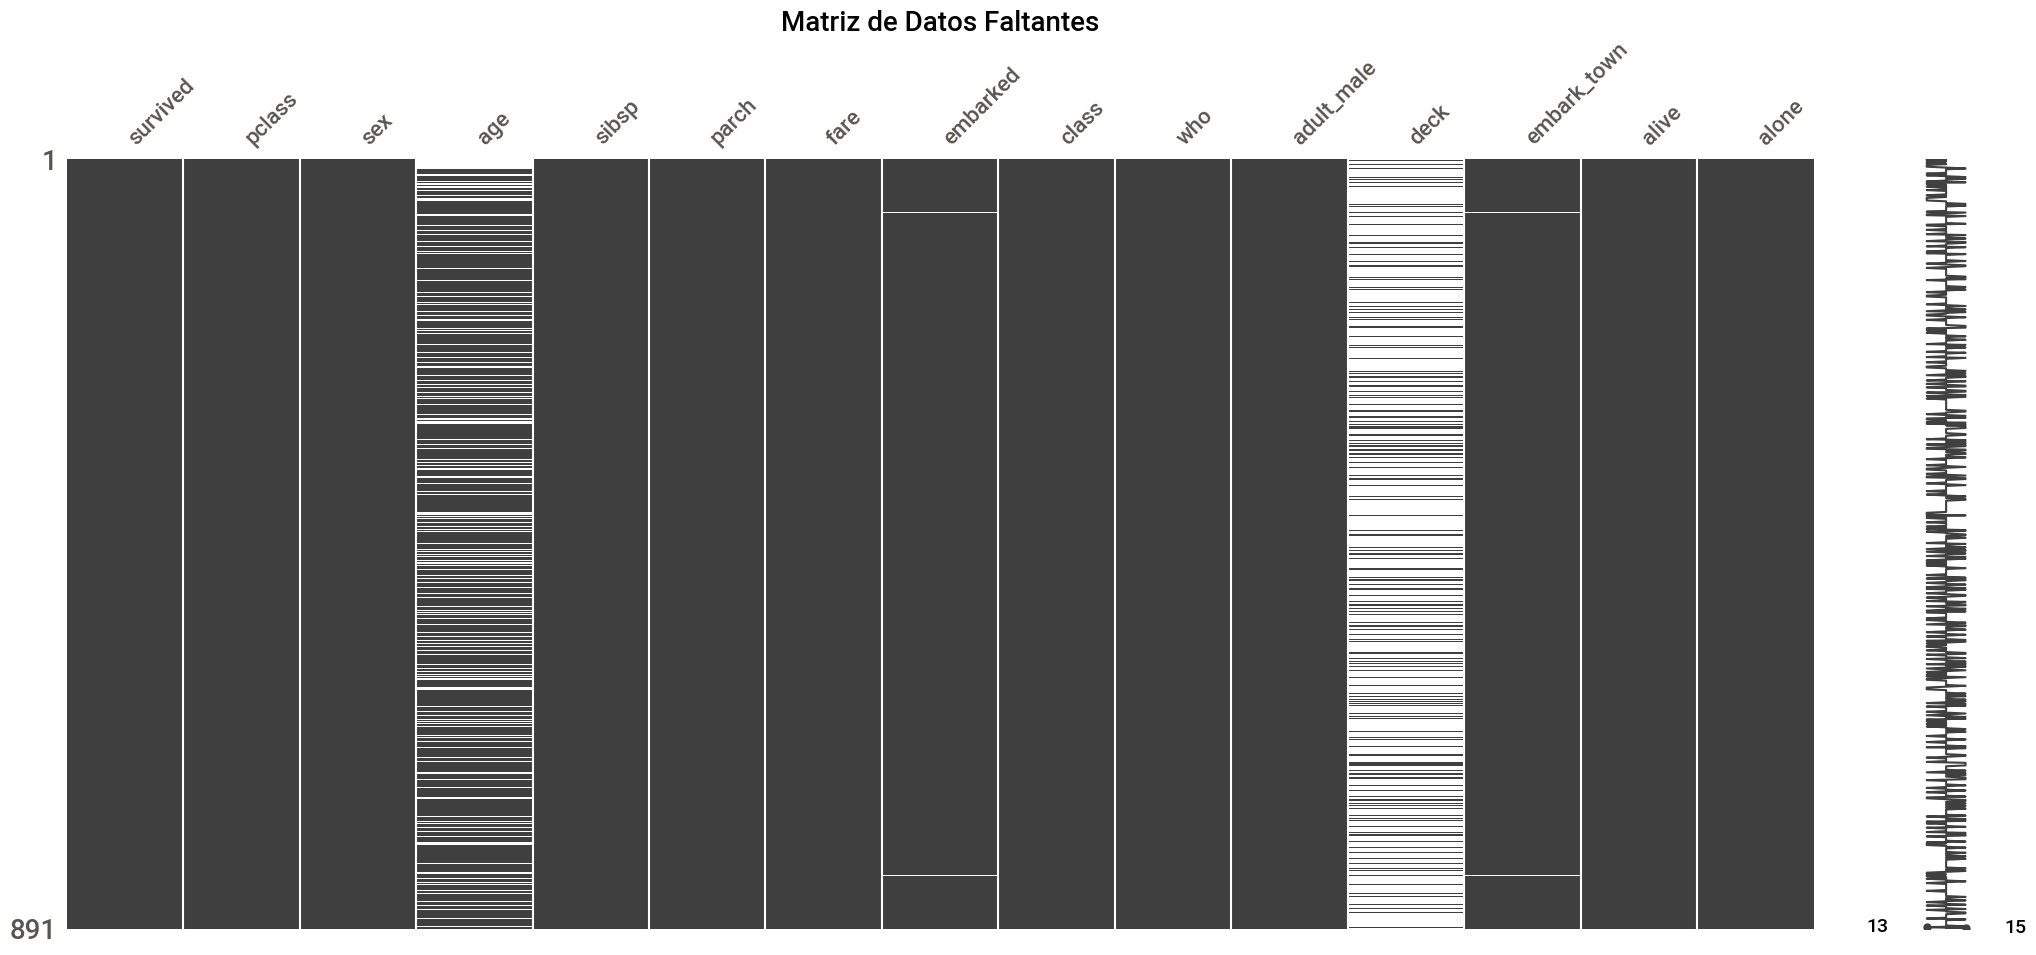

In [21]:
# Matriz de nulos: Líneas blancas = dato faltante
msno.matrix(df)
plt.title("Matriz de Datos Faltantes", fontsize=20)
plt.show()

También podemos ver si la falta de datos en una columna está **correlacionada** con otra. 

*   **1**: Si falta X, siempre falta Y.
*   **-1**: Si falta X, nunca falta Y.

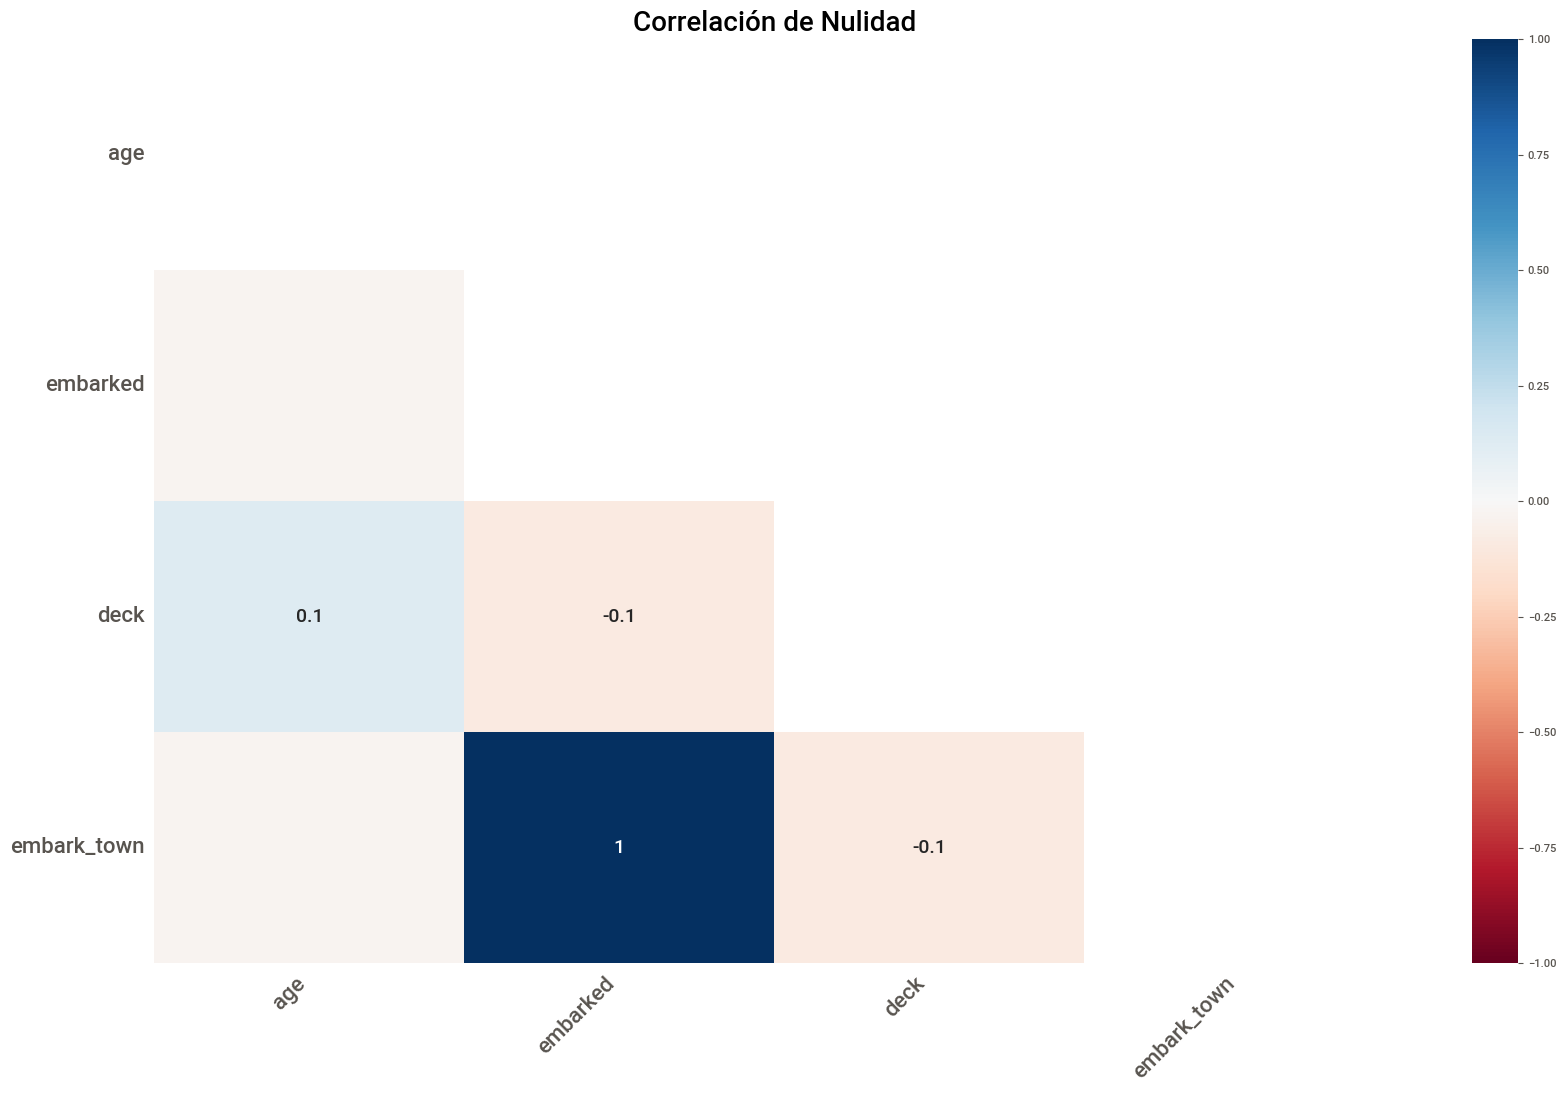

In [22]:
msno.heatmap(df)
plt.title("Correlación de Nulidad", fontsize=20)
plt.show()

---
## 3. 🎛️ Exploración Interactiva (D-Tale)

**D-Tale** lanza una mini-aplicación web local donde puedes filtrar, ordenar, hacer gráficos y editar datos como si fuera Excel, pero conectado a tu DataFrame de pandas.

*Nota: Esto abrirá una herramienta interactiva. Puede que necesites permiso de firewall o que solo funcione mientras la celda corre.*

In [ ]:
import dtale
import re

print("Iniciando D-Tale...")
d = dtale.show(df, host='127.0.0.1')

# Solución definitiva para el enlace:
# Obtenemos la URL que genera D-Tale y reemplazamos cualquier host por 127.0.0.1
try:
    # Intentamos obtener la URL oficial
    full_url = d._main_url
    # Reemplazamos el host (sea laptop-xxx o lo que sea) por 127.0.0.1 preservando el puerto
    local_url = re.sub(r'(http://)[^:]+(:)', r'127.0.0.1\2', full_url)
    print(f"👉 Haz clic en este enlace para entrar: {local_url}")
except Exception as e:
    print(f"No se pudo generar el enlace: {e}")
    print("Intenta simplemente: http://127.0.0.1:40000/dtale/main/1 (El puerto puede variar)")

Iniciando D-Tale...
👉 Haz clic en este enlace para entrar: 127.0.0.1:40000/dtale/main/1


2026-01-21 19:46:09,990 - INFO     - Executing shutdown...
2026-01-21 19:46:09,993 - INFO     - Not running with the Werkzeug Server, exiting by searching gc for BaseWSGIServer


---
## 4. 📉 Automatizando la Detección de Outliers

Los valores extremos pueden arruinar tus modelos. Vamos a crear una **función reutilizable** que limpie cualquier dataset usando el método del Rango Intercuartílico (IQR).

In [24]:
def remove_outliers_iqr(df, columns, threshold=1.5):
    """
    Elimina outliers de columnas específicas usando el método IQR.
    
    Params:
        df: DataFrame original
        columns: Lista de columnas numéricas a limpiar
        threshold: Multiplicador del IQR (1.5 es estándar, 3 es extremo)
    
    Returns:
        df_clean: DataFrame sin outliers
    """
    df_clean = df.copy()
    indices_to_drop = []
    
    for col in columns:
        # Calcular cuartiles
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Definir límites
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        
        # Encontrar outliers
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].index
        indices_to_drop.extend(outliers)
        
        print(f"Columna '{col}': {len(outliers)} outliers detectados.")
    
    # Eliminar duplicados (si una fila es outlier por varias columnas)
    indices_to_drop = list(set(indices_to_drop))
    df_clean = df_clean.drop(indices_to_drop)
    
    print(f"\nTotal filas eliminadas: {len(indices_to_drop)}")
    print(f"Tamaño original: {df.shape} -> Tamaño limpio: {df_clean.shape}")
    
    return df_clean

# Probemos con la columna 'fare' donde insertamos valores de 1000
df_clean = remove_outliers_iqr(df, columns=['fare', 'age'])

Columna 'fare': 121 outliers detectados.
Columna 'age': 8 outliers detectados.

Total filas eliminadas: 128
Tamaño original: (891, 15) -> Tamaño limpio: (763, 15)


---
## 5. 🧩 Imputación Inteligente (KNNImputer)

Reemplazar nulos con el `promedio` es básico y a veces peligroso (distorsiona la realidad).

**KNN (K-Nearest Neighbors)** busca a los "vecinos más cercanos" (filas similares) y usa sus valores para rellenar el hueco. 

*Ejemplo: Si falta la edad de un pasajero, KNN busca pasajeros con la misma clase, precio de boleto y sexo, y usa su edad promedio.*

In [25]:
# KNNImputer solo funciona con números. Seleccionemos columnas numéricas.
cols_numeric = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

imputer = KNNImputer(n_neighbors=5)

# Ajustar y transformar
df_imputed_array = imputer.fit_transform(df[cols_numeric])

# Volver a DataFrame
df_imputed = pd.DataFrame(df_imputed_array, columns=cols_numeric)

# Verificamos si quedan nulos en Age
print("Nulos en Age antes:", df['age'].isnull().sum())
print("Nulos en Age después:", df_imputed['age'].isnull().sum())

display(df_imputed.head(10))

Nulos en Age antes: 187
Nulos en Age después: 0


,survived,pclass,age,sibsp,parch,fare
0,0.0,3.0,24.4,1.0,0.0,7.2500
1,1.0,1.0,35.0,1.0,0.0,71.2833
2,1.0,3.0,34.6,0.0,0.0,7.9250
3,1.0,1.0,31.6,1.0,0.0,53.1000
4,0.0,3.0,24.5,0.0,0.0,8.0500
5,0.0,3.0,25.0,0.0,0.0,8.4583
6,0.0,1.0,37.2,0.0,0.0,51.8625
7,0.0,3.0,18.0,3.0,1.0,21.0750
8,1.0,3.0,3.0,0.0,2.0,11.1333
9,1.0,2.0,36.5,1.0,0.0,30.0708


---
## 6. 🔢 Feature Encoding

Los modelos de IA solo entienden números. ¿Qué hacemos con "Hombre/Mujer" o "Southampton/Cherbourg"?

### A. One-Hot Encoding
Crea una columna nueva para cada categoría (sí/no).
*   Ideal para: Pocas categorías (ej. Sexo, Clase).
*   Problema: Si tienes 100 países, creas 100 columnas (Maldición de la Dimensionalidad).

In [26]:
# Pandas lo hace muy fácil con get_dummies
df_onehot = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)
# drop_first=True elimina una columna redundante (si no es mujer, es hombre)

display(df_onehot.head())

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,deck,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,NaN,1,0,7.2500,Third,man,True,NaN,Southampton,no,False,True,False,True
1,1,1,NaN,1,0,71.2833,First,woman,False,C,Cherbourg,yes,False,False,False,False
2,1,3,NaN,0,0,7.9250,Third,woman,False,NaN,Southampton,yes,True,False,False,True
3,1,1,NaN,1,0,53.1000,First,woman,False,C,Southampton,yes,False,False,False,True
4,0,3,NaN,0,0,8.0500,Third,man,True,NaN,Southampton,no,True,True,False,True


### B. Target Encoding
Si tienes MUCHAS categorías (ej. Código Postal), One-Hot es malo. 

**Target Encoding** reemplaza la categoría con el **promedio de la variable objetivo** (target) para esa categoría.
*   Ejemplo: Reemplazar "Paris" por el % de supervivencia de la gente de Paris.

In [27]:
# Supongamos que queremos predecir 'survived' usando 'deck' (que tiene muchas letras, o muchos nulos)
# Primero limpiemos nulos de deck para el ejemplo
df['deck'] = df['deck'].astype(str)

encoder = TargetEncoder(cols=['deck'])

# El encoder necesita saber el Target (y) para aprender los promedios
df['deck_encoded'] = encoder.fit_transform(df['deck'], df['survived'])

display(df[['deck', 'deck_encoded', 'survived']].head(10))

,deck,deck_encoded,survived
0,nan,0.299419,0
1,C,0.589066,1
2,nan,0.299419,1
3,C,0.589066,1
4,nan,0.299419,0
5,nan,0.299419,0
6,E,0.665243,0
7,nan,0.299419,0
8,nan,0.299419,1
9,nan,0.299419,1


---
## 🎓 Resumen

Hoy has aprendido a:
1.  **Acelerar** el análisis con **Sweetviz** 🚀.
2.  **Visualizar** lo invisible (nulos) con **Missingno** 🔍.
3.  **Interactuar** con tus datos usando **D-Tale** 🎛️.
4.  **Limpiar** outliers automáticamente con tu función personalizada 📉.
5.  **Imputar** datos como un pro usando **KNN** 🧠.
6.  **Traducir** texto a números con **Encoding** 🔢.

¡Estas herramientas te diferenciarán de un analista principiante!